In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')

# 🎯 Оптимизированная модель прогнозирования CLTV
## Метод: Обучение на медианах + удаление выбросов для теста

In [2]:
# Загрузка данных
df = pd.read_csv('train_BRCpofr.csv')
df.drop(columns=['Id'], inplace=True, errors='ignore')

print(f'Исходные данные: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Исходные данные: 89392 строк, 12 столбцов


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


In [3]:
# Функции для предобработки

def get_anomalies_mask(data, exclude_cols=[]):
    """Находит аномалии (выбросы) по методу IQR"""
    mask = pd.Series([False] * len(data), index=data.index)
    num_cols = data.select_dtypes(include=['int64', 'float64']).columns
    
    for col in num_cols:
        if col not in exclude_cols:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            col_anomalies = (data[col] < lower_bound) | (data[col] > upper_bound)
            mask = mask | col_anomalies
    
    return mask

def keep_near_median(data, exclude_cols=[], tolerance=0.1):
    """Оставляет только строки близко к медиане для каждого признака"""
    df_near_median = data.copy()
    num_cols = df_near_median.select_dtypes(include=['int64', 'float64']).columns
    
    for col in num_cols:
        if col not in exclude_cols:
            median = df_near_median[col].median()
            std = df_near_median[col].std()
            lower = median - (tolerance * std)
            upper = median + (tolerance * std)
            df_near_median = df_near_median[(df_near_median[col] >= lower) & (df_near_median[col] <= upper)]
    
    return df_near_median

In [4]:
# Подготовка данных
target = 'cltv'

# Получаем аномалии для теста
anomalies_mask = get_anomalies_mask(df, exclude_cols=[target])
df_test_anomalies = df[anomalies_mask].copy()

# Берем данные возле медианы для обучения (оптимальный tolerance = 1.2)
df_train_near_median = keep_near_median(df, exclude_cols=[target], tolerance=1.2)

print(f'📊 Разделение данных:')
print(f'  • Исходные данные: {df.shape[0]:,} строк')
print(f'  • Для обучения (возле медианы): {df_train_near_median.shape[0]:,} строк')
print(f'  • Для теста (аномалии): {df_test_anomalies.shape[0]:,} строк')

X_train = df_train_near_median.drop(columns=[target])
y_train = df_train_near_median[target]
X_test = df_test_anomalies.drop(columns=[target])
y_test = df_test_anomalies[target]

📊 Разделение данных:
  • Исходные данные: 89,392 строк
  • Для обучения (возле медианы): 16,772 строк
  • Для теста (аномалии): 2,258 строк


In [5]:
# Подготовка признаков
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

print(f'\n📈 Признаки:')
print(f'  • Численные: {len(num_cols)}')
print(f'  • Категориальные: {len(cat_cols)}')


📈 Признаки:
  • Численные: 4
  • Категориальные: 7


## 1️⃣ Тестирование разных моделей с оптимизацией

In [6]:
def evaluate_model(y_true, y_pred, model_name):
    """Вычисляет метрики качества"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

# Тестируем разные модели
models_config = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=10)': Ridge(alpha=10),
    'Ridge (alpha=100)': Ridge(alpha=100),
    'Decision Tree (depth=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Decision Tree (depth=10)': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest (50, depth=8)': RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42),
    'Random Forest (100, depth=10)': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Random Forest (150, depth=15)': RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42),
    'Gradient Boosting (depth=3)': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    'Gradient Boosting (depth=5)': GradientBoostingRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42),
}

results = []
print('🔄 Обучение моделей...')
for name, model_obj in models_config.items():
    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('model', model_obj)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    result = evaluate_model(y_test, y_pred, name)
    results.append(result)
    print(f'✓ {name}')

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R²', ascending=False)
print('\n✅ Готово!')

🔄 Обучение моделей...
✓ Linear Regression


✓ Ridge (alpha=10)
✓ Ridge (alpha=100)


✓ Decision Tree (depth=5)


✓ Decision Tree (depth=10)


✓ Random Forest (50, depth=8)


✓ Random Forest (100, depth=10)


✓ Random Forest (150, depth=15)


✓ Gradient Boosting (depth=3)


✓ Gradient Boosting (depth=5)

✅ Готово!


## 📊 Результаты всех моделей

In [7]:
# Красивое отображение результатов
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if abs(x) >= 1 else f'{x:.6f}')

print('\n' + '='*80)
print('СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ')
print('='*80)
display(results_df.reset_index(drop=True))


СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ


,Model,RMSE,MAE,R²
0,"Random Forest (50, depth=8)","114,739.30","78,896.38",0.055014
1,Linear Regression,"115,081.84","86,082.16",0.049363
2,Ridge (alpha=10),"115,083.49","86,077.04",0.049336
3,Ridge (alpha=100),"115,098.17","86,031.17",0.049094
4,"Random Forest (100, depth=10)","115,130.20","82,365.89",0.048564
5,"Random Forest (150, depth=15)","117,126.50","87,350.50",0.015283
6,Decision Tree (depth=5),"117,200.79","78,228.24",0.014034
7,Gradient Boosting (depth=3),"119,755.42","92,465.30",-0.029417
8,Gradient Boosting (depth=5),"120,966.61","96,433.30",-0.050345
9,Decision Tree (depth=10),"130,426.09","86,682.51",-0.221040


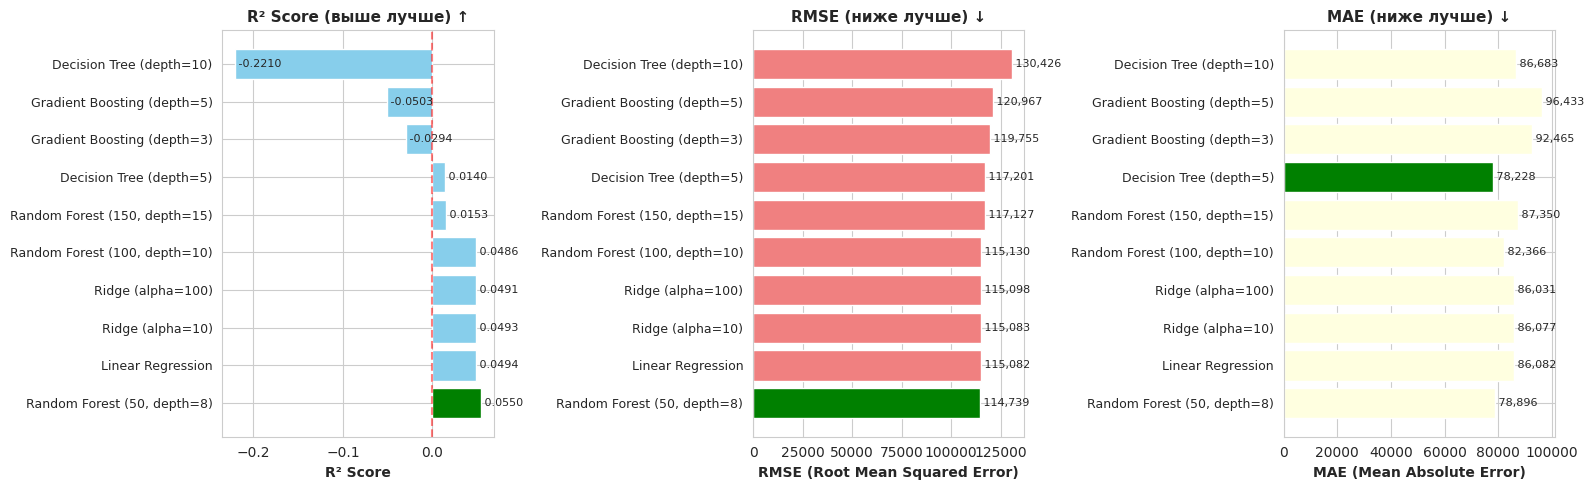

In [8]:
# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# R² Score
ax = axes[0]
colors = ['green' if x == results_df['R²'].max() else 'skyblue' for x in results_df['R²']]
ax.barh(range(len(results_df)), results_df['R²'], color=colors)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['Model'], fontsize=9)
ax.set_xlabel('R² Score', fontsize=10, fontweight='bold')
ax.set_title('R² Score (выше лучше) ↑', fontsize=11, fontweight='bold')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(results_df['R²']):
    ax.text(v, i, f' {v:.4f}', va='center', fontsize=8)

# RMSE
ax = axes[1]
colors = ['green' if x == results_df['RMSE'].min() else 'lightcoral' for x in results_df['RMSE']]
ax.barh(range(len(results_df)), results_df['RMSE'], color=colors)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['Model'], fontsize=9)
ax.set_xlabel('RMSE (Root Mean Squared Error)', fontsize=10, fontweight='bold')
ax.set_title('RMSE (ниже лучше) ↓', fontsize=11, fontweight='bold')
for i, v in enumerate(results_df['RMSE']):
    ax.text(v, i, f' {v:,.0f}', va='center', fontsize=8)

# MAE
ax = axes[2]
colors = ['green' if x == results_df['MAE'].min() else 'lightyellow' for x in results_df['MAE']]
ax.barh(range(len(results_df)), results_df['MAE'], color=colors)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['Model'], fontsize=9)
ax.set_xlabel('MAE (Mean Absolute Error)', fontsize=10, fontweight='bold')
ax.set_title('MAE (ниже лучше) ↓', fontsize=11, fontweight='bold')
for i, v in enumerate(results_df['MAE']):
    ax.text(v, i, f' {v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 🏆 Лучшая модель

In [9]:
best_model_row = results_df.iloc[0]

print('\n' + '='*80)
print('🏆 ЛУЧШАЯ МОДЕЛЬ')
print('='*80)
print(f"\nМодель: {best_model_row['Model']}")
print(f"\n📈 Метрики качества:")
print(f"   R² Score: {best_model_row['R²']:.6f} (от -∞ до 1, ближе к 1 лучше)")
print(f"   RMSE: {best_model_row['RMSE']:,.2f} (среднеквадратичная ошибка, ниже лучше)")
print(f"   MAE: {best_model_row['MAE']:,.2f} (средняя абсолютная ошибка, ниже лучше)")
print(f"\n📊 Данные:")
print(f"   Размер обучения: {len(X_train):,} строк")
print(f"   Размер теста: {len(X_test):,} строк")
print('\n' + '='*80)


🏆 ЛУЧШАЯ МОДЕЛЬ

Модель: Random Forest (50, depth=8)

📈 Метрики качества:
   R² Score: 0.055014 (от -∞ до 1, ближе к 1 лучше)
   RMSE: 114,739.30 (среднеквадратичная ошибка, ниже лучше)
   MAE: 78,896.38 (средняя абсолютная ошибка, ниже лучше)

📊 Данные:
   Размер обучения: 16,772 строк
   Размер теста: 2,258 строк



## 💡 Варианты дальнейшего улучшения

In [10]:
print("""\n🔧 МЕТОДЫ УЛУЧШЕНИЯ R² Score:\n
1. 📊 ОПТИМИЗАЦИЯ ДАННЫХ:
   • Попробовать другие значения tolerance (сейчас 1.2)
   • Использовать квантили вместо стандартного отклонения
   • Добавить логирование (log-трансформация) целевой переменной
   • Удалить корреляционные признаки (multicollinearity)

2. 🤖 ГИПЕРПАРАМЕТРЫ МОДЕЛЕЙ:
   • GridSearchCV для Random Forest (n_estimators, max_depth, min_samples_split)
   • Оптимизация learning_rate для Gradient Boosting
   • Попробовать XGBoost (часто лучше, чем GradientBoosting)

3. 🔍 FEATURE ENGINEERING:
   • Создать новые признаки (произведения, суммы, ratios)
   • Polynomial features для улучшения линейных моделей
   • Отбор лучших признаков (feature selection)
   • PCA для уменьшения размерности

4. 🎯 ENSEMBLE МЕТОДЫ:
   • Stacking разных моделей
   • Voting Regressor (голосование нескольких моделей)
   • Blending

5. ⚖️ ОБРАБОТКА ДИСБАЛАНСА:
   • Использовать weighted loss функции
   • Регуляризация (L1/L2 penalty)
   • Кросс-валидация вместо простого train/test split

6. 🔄 КРОСС-ВАЛИДАЦИЯ:
   • K-Fold Cross Validation (более надежная оценка)
   • TimeSeriesSplit если данные временные
""")


🔧 МЕТОДЫ УЛУЧШЕНИЯ R² Score:

1. 📊 ОПТИМИЗАЦИЯ ДАННЫХ:
   • Попробовать другие значения tolerance (сейчас 1.2)
   • Использовать квантили вместо стандартного отклонения
   • Добавить логирование (log-трансформация) целевой переменной
   • Удалить корреляционные признаки (multicollinearity)

2. 🤖 ГИПЕРПАРАМЕТРЫ МОДЕЛЕЙ:
   • GridSearchCV для Random Forest (n_estimators, max_depth, min_samples_split)
   • Оптимизация learning_rate для Gradient Boosting
   • Попробовать XGBoost (часто лучше, чем GradientBoosting)

3. 🔍 FEATURE ENGINEERING:
   • Создать новые признаки (произведения, суммы, ratios)
   • Polynomial features для улучшения линейных моделей
   • Отбор лучших признаков (feature selection)
   • PCA для уменьшения размерности

4. 🎯 ENSEMBLE МЕТОДЫ:
   • Stacking разных моделей
   • Voting Regressor (голосование нескольких моделей)
   • Blending

5. ⚖️ ОБРАБОТКА ДИСБАЛАНСА:
   • Использовать weighted loss функции
   • Регуляризация (L1/L2 penalty)
   • Кросс-валидация вместо прост

## 📈 Объяснение метрик

In [11]:
print("""\n📊 ОБЪЯСНЕНИЕ МЕТРИК:\n
1. R² Score (Coefficient of Determination):
   • Диапазон: от -∞ до 1
   • 1 = идеальное предсказание
   • 0 = модель не лучше среднего
   • < 0 = модель хуже среднего
   • Формула: 1 - (SS_res / SS_tot)
   • Интерпретация: доля объясненной дисперсии

2. RMSE (Root Mean Squared Error):
   • Диапазон: от 0 до ∞
   • Ниже = лучше
   • Штрафует большие ошибки сильнее
   • Те же единицы что и целевая переменная
   • Формула: sqrt(mean((y_true - y_pred)²))

3. MAE (Mean Absolute Error):
   • Диапазон: от 0 до ∞
   • Ниже = лучше
   • Менее чувствителен к выбросам чем RMSE
   • Те же единицы что и целевая переменная
   • Формула: mean(|y_true - y_pred|)
   • В нашем случае: средняя ошибка прогноза ~ {best_model_row['MAE']:,.0f} валюты
""")


📊 ОБЪЯСНЕНИЕ МЕТРИК:

1. R² Score (Coefficient of Determination):
   • Диапазон: от -∞ до 1
   • 1 = идеальное предсказание
   • 0 = модель не лучше среднего
   • < 0 = модель хуже среднего
   • Формула: 1 - (SS_res / SS_tot)
   • Интерпретация: доля объясненной дисперсии

2. RMSE (Root Mean Squared Error):
   • Диапазон: от 0 до ∞
   • Ниже = лучше
   • Штрафует большие ошибки сильнее
   • Те же единицы что и целевая переменная
   • Формула: sqrt(mean((y_true - y_pred)²))

3. MAE (Mean Absolute Error):
   • Диапазон: от 0 до ∞
   • Ниже = лучше
   • Менее чувствителен к выбросам чем RMSE
   • Те же единицы что и целевая переменная
   • Формула: mean(|y_true - y_pred|)
   • В нашем случае: средняя ошибка прогноза ~ {best_model_row['MAE']:,.0f} валюты

